
# Tarea 1 Fundamentos de Aprendizaje Profundo

### Vicente Mieres



In [26]:
# imports y setup
import os, math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import json
from ucimlrepo import fetch_ucirepo
import optuna
from optuna.trial import TrialState


torch.set_float32_matmul_precision('high')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('checkpoints', exist_ok=True)
print('Device:', DEVICE)

Device: cuda


## 1. Introducción

El siguiente notebook busca resolver la tarea número 1 del curso Fund. Apr. Automático. Esta tiene como objetivo realizar la implementación y ejecución de disintos modelos utilizando un red feed forward al estilo pytorch. Para esto se realizó un grid search tanto manual, como con la herramienta Optuna. Más detalles se encuentran las siguientes secciones.

Para este trabajo se escogió el dataset 'Online News Popularity' (https://archive.ics.uci.edu/dataset/332/online+news+popularity). 

## 2. Funciones

A continuación se muestra la implementación de diferentes funciones necesarias para la creación de los modelos. Entre ellas se encuentras las funciones que inician los pesos del modelo, el *fit* del mismo, y su *evaluate*. También se especifican funciones para gráficas las claes FFNN y FFNN_MC (FFNN: Feed Forward Neural Network).

In [27]:
# Función para inicializar los pesos
def init_weights(m, init_method='he'):
    if isinstance(m, nn.Linear):
        if init_method == 'he':
            # Inicialización He (buena para ReLU)
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        elif init_method == 'xavier':
            # Inicialización Xavier (buena para Tanh o Sigmoid)
            nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def make_mlp(d_in: int, d_hidden=(64, 64), d_out=1, dropout=0.0, 
             act_fn=nn.ReLU, # <--- CAMBIADO (ahora es un parámetro)
             use_bn=False):
    layers = []
    d_prev = d_in
    for i, h in enumerate(d_hidden):
        layers.append(nn.Linear(d_prev, h))
        if use_bn:
            layers.append(nn.BatchNorm1d(h))
        layers.append(act_fn()) # <--- Usa la función de activación
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        d_prev = h
    layers.append(nn.Linear(d_prev, d_out))
    return nn.Sequential(*layers)

@torch.no_grad()
def accuracy_bin(logits, y_true):
    preds = (logits.sigmoid() >= 0.5).float().view(-1)
    return (preds == y_true.view(-1)).float().mean().item()

@torch.no_grad()
def accuracy_multi(logits, y_true):
    preds = logits.argmax(1)
    return (preds == y_true).float().mean().item()

def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def fit(model, train_ds, val_ds=None, *, epochs=100, batch_size=64, lr=1e-3,
        patience=10, min_delta=1e-4, ckpt_path=None, compile_model=True, 
        weight_decay=0.0, optimizer_name='AdamW'):
    
    model.to(DEVICE)
    if compile_model and hasattr(torch, 'compile') and os.name != 'nt':
        try:
            model = torch.compile(model)
        except Exception as e:
            print('torch.compile no disponible:', e)

    sample_x, sample_y = train_ds[0][0], train_ds[0][1]
    # binary = sample_y.ndim == 0 or sample_y.unique().numel() <= 2
    binary = (sample_y.dtype == torch.float32)

    
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'adamw':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        print(f"Advertencia: Optimizador '{optimizer_name}' no reconocido. Usando AdamW.")
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # --- AÑADIR ESTO: LR SCHEDULER ---
    # Reduce el LR por un factor de 0.2 si val_loss no mejora en 5 épocas
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.2, patience=5, min_lr=1e-6)
    # ------------------------------------

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    best = math.inf; best_epoch = None; best_state = None
    history = {'epoch': [], 'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    history['epoch_best'] = None 

    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0; n = 0; accs = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            if binary:
                yb_f = yb.float().view(-1,1)
                loss = criterion(logits, yb_f)
                acc = accuracy_bin(logits.detach(), yb.detach().float())
            else:
                loss = criterion(logits, yb.long())
                acc = accuracy_multi(logits.detach(), yb.detach().long())
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            epoch_loss += loss.item()*xb.size(0); n += xb.size(0); accs.append(acc)
        tr_loss = epoch_loss/n; tr_acc = float(np.mean(accs))

        # Validación
        if val_ds is not None:
            model.eval()
            val_loader = DataLoader(val_ds, batch_size=batch_size * 2)
            val_loss_epoch = 0.0; val_acc_epoch = 0.0; n_val = 0
            with torch.no_grad():
                for xb_val, yb_val in val_loader:
                    xb_val, yb_val = xb_val.to(DEVICE), yb_val.to(DEVICE)
                    logits = model(xb_val)
                    if binary:
                        val_loss = criterion(logits, yb_val.float().view(-1,1)).item()
                        val_acc = accuracy_bin(logits, yb_val.float())
                    else:
                        val_loss = criterion(logits, yb_val.long()).item()
                        val_acc = accuracy_multi(logits, yb_val.long())
                    val_loss_epoch += val_loss * xb_val.size(0)
                    val_acc_epoch += val_acc * xb_val.size(0)
                    n_val += xb_val.size(0)
            
            val_loss = val_loss_epoch / n_val
            val_acc = val_acc_epoch / n_val

            scheduler.step(val_loss) 
            
            if val_loss + min_delta < best:
                best = val_loss; best_epoch = epoch; best_state = {k:v.cpu() for k,v in model.state_dict().items()}
                if ckpt_path: torch.save(best_state, ckpt_path)

        history['epoch'].append(epoch)
        history['loss'].append(tr_loss); history['acc'].append(tr_acc)
        if val_ds is not None:
            history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

        if epoch % 5 == 0:
            msg = f"[{epoch:03d}] loss={tr_loss:.4f} acc={tr_acc*100:5.1f}%"
            if val_ds is not None:
                # Mostrar el LR actual
                current_lr = opt.param_groups[0]['lr']
                msg += f" | vloss={val_loss:.4f} vacc={val_acc*100:5.1f}% (LR: {current_lr:.1e})"
            print(msg)

        if val_ds is not None and (epoch - (best_epoch or 0)) >= patience:
            print(f"Paro temprano @ epoch {epoch} (best={best_epoch})\n")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    
    history['epoch_best'] = best_epoch 

    return model, history, best_epoch

In [28]:
# FFNN
class FFNN(nn.Module):
    # Binario: salida 1
    def __init__(self, d0, d_hidden=(64, 64), dropout=0.0, use_bn=False, 
                 init_method='he', act_fn=nn.ReLU): # <--- AÑADIDO act_fn
        super().__init__()
        self.net = make_mlp(d0, d_hidden, 1, dropout=dropout, 
                            act_fn=act_fn, use_bn=use_bn) # <--- Pasado a make_mlp
        self.net.apply(lambda m: init_weights(m, init_method=init_method))
        
    def forward(self, x): 
        return self.net(x)

class FFNN_MC(nn.Module):
    # Multiclase: salida C
    def __init__(self, d0, d_hidden=(64, 64), C=3, dropout=0.0, 
                 use_bn=False, init_method='he', 
                 act_fn=nn.ReLU): # <--- AÑADIDO act_fn
        super().__init__()
        self.net = make_mlp(d0, d_hidden, C, dropout=dropout, 
                            act_fn=act_fn, use_bn=use_bn) # <--- Pasado a make_mlp
        self.net.apply(lambda m: init_weights(m, init_method=init_method))

    def forward(self, x): 
        return self.net(x)

In [29]:

# evaluation & plotting
@torch.no_grad()
def evaluate(model, dataset, binary=True, batch_size=256):
    model.eval(); loader = DataLoader(dataset, batch_size=batch_size)
    total=0; correct=0; losses=[]; crit = nn.BCEWithLogitsLoss() if binary else nn.CrossEntropyLoss()
    all_y=[]; all_p=[]
    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        logits = model(xb)
        if binary:
            loss = crit(logits, yb.float().view(-1,1))
            preds = (logits.sigmoid()>=0.5).float().view(-1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        else:
            loss = crit(logits, yb.long())
            preds = logits.argmax(1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        total += yb.size(0); correct += (preds == yb.view(-1)).float().sum().item(); losses.append(loss.item())
    acc = correct/total
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    cm = confusion_matrix(y_true, y_pred)

    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {'acc': acc, 'loss': float(np.mean(losses)), 'cm': cm, 'report_dict': rep}

@torch.no_grad()
def evaluate_per_class(model, dataset, binary=False, batch_size=256):
    # simple wrapper que devuelve matriz de confusión y métricas por clase del classification_report
    e = evaluate(model, dataset, binary=binary, batch_size=batch_size)
    return e

def plot_history_loss(h):
    x = h['epoch'];
    plt.figure(); plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss'): plt.plot(x, h['val_loss'], label='val_loss')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Histórico Loss'); plt.legend(); plt.show()

def plot_history_acc(h):
    x = h['epoch'];
    plt.figure(); plt.plot(x, np.array(h['acc'])*100, label='train_acc')
    if h.get('val_acc'): plt.plot(x, np.array(h['val_acc'])*100, label='val_acc')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title('Histórico Acc'); plt.legend(); plt.show()

def plot_with_best_epoch(h, best_epoch):
    plot_history_loss(h); plot_history_acc(h)
    if best_epoch:
        print(f"Mejor época (val_loss): {best_epoch}")


In [30]:

# [plots with best epoch]
def plot_history(h, best_epoch=None, title='Histórico'):
    x = h['epoch']
    # Loss
    plt.figure()
    plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss') and len(h['val_loss']) == len(x):
        plt.plot(x, h['val_loss'], label='val_loss')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--')
        plt.text(best_epoch, plt.ylim()[1]*0.9, f"best={best_epoch}", rotation=90, va='top')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title(title + ' - Loss'); plt.legend(); plt.show()
    # Acc
    plt.figure()
    plt.plot(x, [a*100 for a in h['acc']], label='train_acc')
    if h.get('val_acc') and len(h['val_acc']) == len(x):
        plt.plot(x, [a*100 for a in h['val_acc']], label='val_acc')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--')
        plt.text(best_epoch, plt.ylim()[1]*0.9, f"best={best_epoch}", rotation=90, va='top')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title(title + ' - Acc'); plt.legend(); plt.show()

def plot_with_best_epoch(h, best_epoch):
    plot_history(h, best_epoch=best_epoch, title='Entrenamiento')


## 3. Dataset

Tal como se mencionó anteriormente, el dataset escodigo corresponde a 'Online News Popularity'. El cual contiene información sobre artículos publicados en el sitio web Mashable (mashable.com) y su desempeño en términos de popularidad medida por número de compartidos (“shares”) en redes sociales. Este suele utilizarse para problemas de regresion y clasificación, para el caso particular de esta entrega, se trabajará bajo un modelo de predicción binario (Popular y No Popular), por lo que se ha transformado la clase objetivo con un umbral ( > 1400 es Popular, caso contrario No lo es).

Cabe destacar el contexto de este problema. El paper asociado a este dataset fue publicado en 2015, por tanto se posiciona previo a cualquier publicación relacionada a problemas de Procesamiento de Lenguaje Natural modernos, principalmente desde 2018 (Transformers). De esta forma contiene diferentes variables que a simple vista podría inducir a sesgo dentro del modelo, tales como el numeor de tokens en el titulo, o dentro del mismo articulo, entre otros. (Esto ahonda en las siguiente secciones)

In [31]:
# Carga del Dataset

np.random.seed(42)
print("Cargando dataset Online News Popularity...")
online_news_popularity = fetch_ucirepo(id=332) 
X_df = online_news_popularity.data.features 
y_df = online_news_popularity.data.targets 

# Binarizar 'y' para clasificación
UMBRAL_POPULARIDAD = 1400 
y_binned = (y_df > UMBRAL_POPULARIDAD).astype(float)

X_data = X_df.to_numpy()
y_data = y_binned.to_numpy()
d0 = X_data.shape[1] # Dimensión de entrada

print(f"Dataset cargado. {X_data.shape[0]} muestras, {d0} características.")
print(f"Problema: Clasificación Binaria (Popular > {UMBRAL_POPULARIDAD} shares)")

# Estandarizar X (¡Muy importante!)
scaler = StandardScaler()
# scaler = MinMaxSca
X_data_scaled = scaler.fit_transform(X_data)


# Dividir en Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_data_scaled, y_data, 
    test_size=0.1, stratify=y_data, random_state=42
)
# Dividir Train en Train/Validación (60/20 del total)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.1, # 0.25 * 0.8 = 0.2 del total
    stratify=y_train, random_state=42
)

# Convertir a TensorDatasets
ds_train = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
ds_val = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
ds_test = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

print(f"Datos divididos: {len(ds_train)} train, {len(ds_val)} val, {len(ds_test)} test")

Cargando dataset Online News Popularity...
Dataset cargado. 39644 muestras, 58 características.
Problema: Clasificación Binaria (Popular > 1400 shares)
Datos divididos: 32111 train, 3568 val, 3965 test


## Grid Search Manual

Como primera tarea a realizar, se configuró una grilla con 12 modelos, los cuales surgen a partir de 2 modelos base (Las variaciones presentadas son netamente aleatorias). 


--- Iniciando Grid Search en cuda ---

--- Entrenando: 1. Base AdamW (64, 64) ---
[005] loss=0.6113 acc= 66.4% | vloss=0.6299 vacc= 66.1% (LR: 1.0e-03)
[010] loss=0.5919 acc= 68.0% | vloss=0.6438 vacc= 65.7% (LR: 1.0e-03)
[015] loss=0.5782 acc= 69.3% | vloss=0.6502 vacc= 65.7% (LR: 2.0e-04)
Paro temprano @ epoch 15 (best=5)

Evaluando 1. Base AdamW (64, 64) en el conjunto de Test...

--- Entrenando: 2. Base SGD (64, 64) + L2 leve ---
[005] loss=0.6597 acc= 60.9% | vloss=0.6479 vacc= 62.4% (LR: 1.0e-03)
[010] loss=0.6473 acc= 62.3% | vloss=0.6385 vacc= 63.5% (LR: 1.0e-03)
[015] loss=0.6414 acc= 63.0% | vloss=0.6340 vacc= 64.5% (LR: 1.0e-03)
[020] loss=0.6373 acc= 63.7% | vloss=0.6313 vacc= 64.5% (LR: 1.0e-03)
[025] loss=0.6339 acc= 64.0% | vloss=0.6290 vacc= 64.7% (LR: 1.0e-03)
[030] loss=0.6312 acc= 64.3% | vloss=0.6277 vacc= 64.9% (LR: 1.0e-03)
[035] loss=0.6288 acc= 64.6% | vloss=0.6266 vacc= 64.9% (LR: 1.0e-03)
[040] loss=0.6269 acc= 64.8% | vloss=0.6252 vacc= 64.9% (LR: 1.0e-03)
[

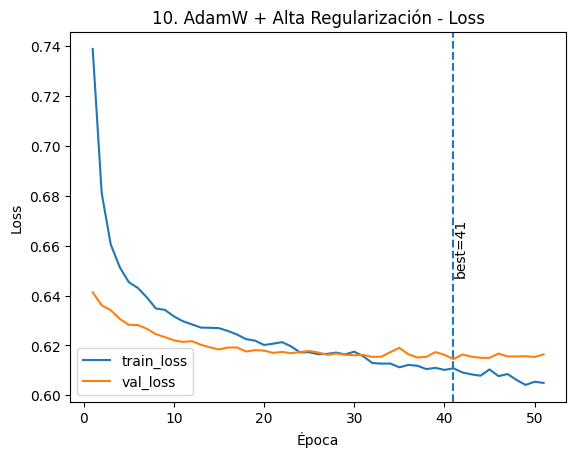

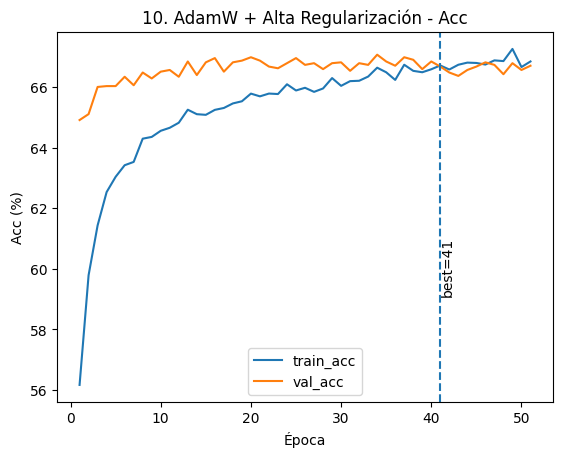

In [32]:
# [Grid Search / Bucle de Experimentos] - (MODIFICADO Y AMPLIADO)

configurations = [
    # --- BASES ---
    {
        "name": "1. Base AdamW (64, 64)",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "he",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },
    {
        "name": "2. Base SGD (64, 64) + L2 leve",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "SGD" 
    },
    
    # --- PRUEBAS DE REGULARIZACIÓN (sobre AdamW) ---
    {
        "name": "3. AdamW + Dropout (0.5)",
        "d_hidden": (64, 64),
        "dropout": 0.5, "use_bn": False, "init_method": "he",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },
    {
        "name": "4. AdamW + L2 (1e-3)",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "he",
        "weight_decay": 1e-3, "optimizer_name": "AdamW" 
    },
    {
        "name": "5. AdamW + Batch Norm",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": True, "init_method": "he",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },

    # --- PRUEBAS DE INICIALIZACIÓN ---
    {
        "name": "6. AdamW + Xavier Init",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "xavier",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },

    # --- PRUEBAS DE ARQUITECTURA ( ---
    {
        "name": "7. Red Profunda (128, 64, 32) + Regs",
        "d_hidden": (128, 64, 32), # 3 capas
        "dropout": 0.3, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "AdamW"
    },
    {
        "name": "8. Red Ancha (256, 128) + Regs",
        "d_hidden": (256, 128), # 2 capas anchas
        "dropout": 0.3, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "AdamW"
    },
    {
        "name": "9. Red Profunda (128, 64, 32) + SGD",
        "d_hidden": (128, 64, 32),
        "dropout": 0.3, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "SGD" 
    },
    {
        "name": "10. AdamW + Alta Regularización",
        "d_hidden": (128, 64),
        "dropout": 0.5, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-3, "optimizer_name": "AdamW" 
    },
    {
        "name": "11. Mejor Modelo + GELU",
        "d_hidden": (128, 64), "dropout": 0.5, "use_bn": True,
        "weight_decay": 1e-3, "optimizer_name": "AdamW", "lr": 1e-3,
        "act_fn": nn.GELU 
    },
    {
        "name": "12. Mejor Modelo + SiLU",
        "d_hidden": (128, 64), "dropout": 0.5, "use_bn": True,
        "weight_decay": 1e-3, "optimizer_name": "AdamW", "lr": 1e-3,
        "act_fn": nn.SiLU 
    }
]

results_summary = []
all_histories = {}
all_models = {}

# Nombres de los archivos de salida
RESULTS_CSV_PATH = "news_popularity_results.csv"
HISTORIES_JSON_PATH = "news_popularity_histories.json"
CHECKPOINTS_DIR = "checkpoints"

print(f"\n--- Iniciando Grid Search en {DEVICE} ---")
if 'd0' not in locals():
    print("ERROR: Por favor, ejecuta la celda [Carga de datos] (Celda 7) primero.")
else:
    for config in configurations:
        print(f"\n--- Entrenando: {config['name']} ---")
        
        set_seed(42)

        # 1. Crear Modelo
        model = FFNN(
            d0, 
            d_hidden=config['d_hidden'],
            dropout=config['dropout'], 
            use_bn=config['use_bn'],
            init_method=config.get('init_method', 'he'),
            act_fn=config.get('act_fn', nn.ReLU)
        )
        
        # 2. Definir ruta para guardar el modelo
        model_filename = config['name'].replace(' ', '_').replace('/', '_') + "_best.pth"
        ckpt_path = os.path.join(CHECKPOINTS_DIR, model_filename)
        
        # 3. Entrenar Modelo
        model, history, best_epoch = fit(
            model, 
            ds_train, 
            val_ds=ds_val,
            epochs=100, 
            lr=1e-3,
            batch_size=256, 
            patience=10, 
            weight_decay=config['weight_decay'],
            optimizer_name=config['optimizer_name'],
            compile_model=False,
            ckpt_path=ckpt_path  
        )
        
        # 4. Evaluar en Test
        print(f"Evaluando {config['name']} en el conjunto de Test...")
        test_eval = evaluate(model, ds_test, binary=True)
        
        # 5. Guardar resultados (MODIFICADO)
        
        summary_data = config.copy()
        summary_data['d_hidden'] = str(summary_data['d_hidden'])
        
        # métricas de entrenamiento
        summary_data['best_epoch'] = best_epoch
        summary_data['total_epochs'] = len(history['epoch'])
        if best_epoch:
            best_idx = best_epoch - 1
            summary_data['best_val_loss'] = history['val_loss'][best_idx]
            summary_data['best_val_acc'] = history['val_acc'][best_idx]
        
        # métricas de Test
        summary_data['test_acc'] = test_eval['acc']
        summary_data['test_loss'] = test_eval['loss']
        
        # Precision, Recall, F1 de la clase 1.0 
        report_class_1 = test_eval['report_dict'].get('1.0', {})
        summary_data['test_precision(1)'] = report_class_1.get('precision')
        summary_data['test_recall(1)'] = report_class_1.get('recall')
        summary_data['test_f1-score(1)'] = report_class_1.get('f1-score')

        results_summary.append(summary_data)
        all_histories[config['name']] = history
        all_models[config['name']] = model 

    print("\n--- Resultados del Grid Search (News Popularity) ---")
    results_df = pd.DataFrame(results_summary).sort_values(by="test_acc", ascending=False)
    
    
    print(results_df.to_markdown(index=False))
    
    # --- GUARDAR ARCHIVOS ---
    
    # 1. Guardar Métricas Clave en CSV
    results_df.to_csv(RESULTS_CSV_PATH, index=False)
    print(f"\nResultados guardados en: {RESULTS_CSV_PATH}")

    # 2. Guardar Historiales en JSON
    with open(HISTORIES_JSON_PATH, "w") as f:
        json.dump(all_histories, f, indent=4)
    print(f"Historiales de entrenamiento guardados en: {HISTORIES_JSON_PATH}")

    # 3. Modelos 
    print(f"Los mejores checkpoints de los modelos se han guardado en la carpeta: '{CHECKPOINTS_DIR}/'")

    # Graficar el historial del mejor modelo
    if not results_df.empty:
        best_model_name = results_df.iloc[0]['name']
        best_model_epoch = results_df.iloc[0]['best_epoch']
        print(f"\n--- Historial del Mejor Modelo: {best_model_name} ---")
        plot_history(all_histories[best_model_name], best_epoch=best_model_epoch, title=best_model_name)
    else:
        print("No se completaron los entrenamientos.")

--- Resultados del Grid Search (News Popularity) ---
| name                                 | d_hidden      |   dropout | use_bn   | init_method   |   weight_decay | optimizer_name   |   best_epoch |   total_epochs |   best_val_loss |   best_val_acc |   test_acc |   test_loss |   test_precision(1) |   test_recall(1) |   test_f1-score(1) |      lr | act_fn                                     |
|:-------------------------------------|:--------------|----------:|:---------|:--------------|---------------:|:-----------------|-------------:|---------------:|----------------:|---------------:|-----------:|------------:|--------------------:|-----------------:|-------------------:|--------:|:-------------------------------------------|
| 10. AdamW + Alta Regularización      | (128, 64)     |       0.5 | True     | he            |         0.001  | AdamW            |           41 |             51 |        0.614519 |       0.66676  |   0.663052 |    0.615362 |            0.650778 |         0.684049 |           0.666999 | nan     | nan                                        |
| 3. AdamW + Dropout (0.5)             | (64, 64)      |       0.5 | False    | he            |         0      | AdamW            |           26 |             36 |        0.628047 |       0.665639 |   0.660782 |    0.623736 |            0.664336 |         0.631391 |           0.647444 | nan     | nan                                        |
| 11. Mejor Modelo + GELU              | (128, 64)     |       0.5 | True     | nan           |         0.001  | AdamW            |           33 |             43 |        0.614301 |       0.662836 |   0.660782 |    0.614842 |            0.654684 |         0.661043 |           0.657848 |   0.001 | <class 'torch.nn.modules.activation.GELU'> |
| 12. Mejor Modelo + SiLU              | (128, 64)     |       0.5 | True     | nan           |         0.001  | AdamW            |           45 |             55 |        0.616001 |       0.665919 |   0.660277 |    0.6165   |            0.647601 |         0.683027 |           0.664842 |   0.001 | <class 'torch.nn.modules.activation.SiLU'> |
| 7. Red Profunda (128, 64, 32) + Regs | (128, 64, 32) |       0.3 | True     | he            |         0.0001 | AdamW            |           20 |             30 |        0.611046 |       0.6662   |   0.659269 |    0.616906 |            0.653631 |         0.657975 |           0.655796 | nan     | nan                                        |
| 8. Red Ancha (256, 128) + Regs       | (256, 128)    |       0.3 | True     | he            |         0.0001 | AdamW            |           17 |             27 |        0.620697 |       0.664518 |   0.656747 |    0.617295 |            0.648084 |         0.665644 |           0.656747 | nan     | nan                                        |
| 6. AdamW + Xavier Init               | (64, 64)      |       0   | False    | xavier        |         0      | AdamW            |            4 |             14 |        0.627451 |       0.660874 |   0.655233 |    0.624484 |            0.65774  |         0.627812 |           0.642427 | nan     | nan                                        |
| 4. AdamW + L2 (1e-3)                 | (64, 64)      |       0   | False    | he            |         0.001  | AdamW            |            5 |             15 |        0.629479 |       0.661715 |   0.647415 |    0.631622 |            0.635306 |         0.669734 |           0.652066 | nan     | nan                                        |
| 5. AdamW + Batch Norm                | (64, 64)      |       0   | True     | he            |         0      | AdamW            |            2 |             12 |        0.62866  |       0.65667  |   0.64691  |    0.634753 |            0.645855 |         0.629346 |           0.637494 | nan     | nan                                        |
| 1. Base AdamW (64, 64)               | (64, 64)      |       0   | False    | he            |         0      | AdamW            |            5 |             15 |        0.629908 |       0.661155 |   0.645649 |    0.631781 |            0.633285 |         0.669223 |           0.650758 | nan     | nan                                        |
| 2. Base SGD (64, 64) + L2 leve       | (64, 64)      |       0   | False    | he            |         0.0001 | SGD              |           99 |            100 |        0.619161 |       0.651065 |   0.642875 |    0.629913 |            0.648189 |         0.603783 |           0.625199 | nan     | nan                                        |
| 9. Red Profunda (128, 64, 32) + SGD  | (128, 64, 32) |       0.3 | True     | he            |         0.0001 | SGD              |           98 |            100 |        0.626188 |       0.65639  |   0.642371 |    0.633903 |            0.63866  |         0.633436 |           0.636037 | nan     | nan                                        |


In [33]:
# Experimento de Bootstrap 

def run_bootstrap_experiment(train_dataset, val_dataset, test_dataset, n_models=10):
    
    print(f"\n--- Iniciando Bootstrap (Bagging) con {n_models} modelos ---")
    
    d0 = train_dataset[0][0].shape[0] 
    ensemble_models = []
    
    for i in range(n_models):
        print(f"Entrenando modelo de bootstrap {i+1}/{n_models}...")
        
        # 1. Crear muestra de bootstrap
        n_train = len(train_dataset)
        indices = torch.randint(0, n_train, (n_train,), device='cpu') 
        bootstrap_train_ds = Subset(train_dataset, indices)
        
        set_seed(42 + i)

        # Mejor configuración obtenida
        model = FFNN(
            d0, 
            d_hidden=(128, 64),     
            dropout=0.5,            
            use_bn=True,            
            init_method='he',
            act_fn=nn.SiLU
        )
        
        model, hist, best = fit(
            model, 
            bootstrap_train_ds, 
            val_ds=val_dataset,
            epochs=100, 
            lr=1e-3,                
            batch_size=256,
            patience=10,
            weight_decay=1e-3,      
            optimizer_name='AdamW', 
            compile_model=False
        )
        
        ensemble_models.append(model)
        
    print("--- Entrenamiento de Bootstrap finalizado ---")
    return ensemble_models

# evaluar un ensemble 
@torch.no_grad()
def evaluate_ensemble(models, test_dataset, binary=True):
    all_preds = []
    
    for model in models:
        model.eval()
        model.to(DEVICE)

    # Obtenemos las predicciones 
    test_loader = DataLoader(test_dataset, batch_size=512)
    all_logits = [[] for _ in models]
    all_yb = []

    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        all_yb.append(yb.cpu())
        
        for i, model in enumerate(models):
            logits = model(xb)
            all_logits[i].append(logits.cpu())

    all_yb_tensor = torch.cat(all_yb, dim=0)
    all_logits_tensor = [torch.cat(logs, dim=0) for logs in all_logits]

    # Predicciones finales de cada modelo
    all_preds = []
    for logits in all_logits_tensor:
        if binary:
            preds = (logits.sigmoid() >= 0.5).float() 
        else:
            preds = logits.argmax(dim=1).float() 
        all_preds.append(preds.view(-1, 1))
    
    all_preds_tensor = torch.cat(all_preds, dim=1)
    
    if binary:
        ensemble_preds = (all_preds_tensor.mean(dim=1) >= 0.5).float()
    else:
        ensemble_preds = torch.mode(all_preds_tensor, dim=1).values
        
    # Calcular precisión final del ensemble
    y_true = all_yb_tensor.float().view(-1)
    acc = (ensemble_preds == y_true).float().mean().item()
    
    print("\n--- Evaluación del Ensemble ---")
    print(f"Precisión del Ensemble (Voto Mayoritario): {acc*100:.2f}%")
    
    print("Reporte de Clasificación del Ensemble:")
    print(classification_report(y_true.numpy(), ensemble_preds.numpy()))
    
    print("Matriz de Confusión del Ensemble:")
    print(confusion_matrix(y_true.numpy(), ensemble_preds.numpy()))
    
    return acc

# --- Ejecutar el experimento de Bootstrap ---
bootstrap_models = run_bootstrap_experiment(ds_train, ds_val, ds_test, n_models=10) 
evaluate_ensemble(bootstrap_models, ds_test, binary=True)


--- Iniciando Bootstrap (Bagging) con 10 modelos ---
Entrenando modelo de bootstrap 1/10...
[005] loss=0.6373 acc= 64.2% | vloss=0.6265 vacc= 65.8% (LR: 1.0e-03)
[010] loss=0.6249 acc= 65.2% | vloss=0.6246 vacc= 66.4% (LR: 1.0e-03)
[015] loss=0.6187 acc= 65.8% | vloss=0.6255 vacc= 66.4% (LR: 1.0e-03)
[020] loss=0.6178 acc= 65.7% | vloss=0.6259 vacc= 66.5% (LR: 2.0e-04)
Paro temprano @ epoch 20 (best=10)

Entrenando modelo de bootstrap 2/10...
[005] loss=0.6422 acc= 63.5% | vloss=0.6235 vacc= 65.6% (LR: 1.0e-03)
[010] loss=0.6280 acc= 64.7% | vloss=0.6222 vacc= 65.9% (LR: 1.0e-03)
[015] loss=0.6220 acc= 65.5% | vloss=0.6219 vacc= 66.1% (LR: 1.0e-03)
[020] loss=0.6169 acc= 65.8% | vloss=0.6240 vacc= 66.3% (LR: 1.0e-03)
[025] loss=0.6138 acc= 66.3% | vloss=0.6246 vacc= 66.1% (LR: 2.0e-04)
Paro temprano @ epoch 25 (best=15)

Entrenando modelo de bootstrap 3/10...
[005] loss=0.6419 acc= 63.3% | vloss=0.6227 vacc= 66.2% (LR: 1.0e-03)
[010] loss=0.6296 acc= 64.6% | vloss=0.6191 vacc= 67.1% (

0.6572509407997131

In [34]:
# Experimento Ensemble Mixto
N_TOP_MODELS_FOR_ENSEMBLE = 5

print(f"\n--- Iniciando Ensemble Mixto (Top {N_TOP_MODELS_FOR_ENSEMBLE} Modelos del Grid Search) ---")

if 'results_df' not in locals():
    print("Error: 'results_df' no encontrado.")
    print("Por favor, ejecuta la celda [Grid Search / Bucle de Experimentos] (Celda 8) primero.")
else:
    top_model_names = results_df.head(N_TOP_MODELS_FOR_ENSEMBLE)['name'].tolist()
    
    print("Modelos seleccionados para el ensemble:")
    for name in top_model_names:
        print(f"- {name}")
        
    mixed_ensemble_models = [all_models[name] for name in top_model_names]

    # Ensemble
    evaluate_ensemble(mixed_ensemble_models, ds_test, binary=True)


--- Iniciando Ensemble Mixto (Top 5 Modelos del Grid Search) ---
Modelos seleccionados para el ensemble:
- 10. AdamW + Alta Regularización
- 3. AdamW + Dropout (0.5)
- 11. Mejor Modelo + GELU
- 12. Mejor Modelo + SiLU
- 7. Red Profunda (128, 64, 32) + Regs

--- Evaluación del Ensemble ---
Precisión del Ensemble (Voto Mayoritario): 66.36%
Reporte de Clasificación del Ensemble:
              precision    recall  f1-score   support

         0.0       0.67      0.65      0.66      2009
         1.0       0.65      0.68      0.66      1956

    accuracy                           0.66      3965
   macro avg       0.66      0.66      0.66      3965
weighted avg       0.66      0.66      0.66      3965

Matriz de Confusión del Ensemble:
[[1310  699]
 [ 635 1321]]


In [35]:
# Busqueda de hiperparámetros con Optuna

# 1. Función Objetivo 
def objective(trial):
      
    set_seed(42) 

    # 1. Arquitectura 
    n_layers = trial.suggest_int('n_layers', 2, 3) # 2-3 capas
    d_hidden_layers = []
    d_h1 = trial.suggest_categorical('d_h1', [64, 128, 256])
    d_h2 = trial.suggest_categorical('d_h2', [32, 64, 128])
    d_hidden_layers.append(d_h1)
    d_hidden_layers.append(d_h2)
    if n_layers == 3:
        d_h3 = trial.suggest_categorical('d_h3', [16, 32, 64])
        d_hidden_layers.append(d_h3)
    d_hidden = tuple(d_hidden_layers)

    # 2. Regularización
    dropout = trial.suggest_float('dropout', 0.0, 0.5, step=0.1)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True) 
    use_bn = trial.suggest_categorical('use_bn', [True, False])

    # 3. Optimizador y Learning Rate
    optimizer_name = trial.suggest_categorical('optimizer_name', ['AdamW', 'SGD'])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    # 4. Función de Activación
    act_fn_str = trial.suggest_categorical('act_fn', ['ReLU', 'GELU', 'SiLU'])
    act_fn_map = {'ReLU': nn.ReLU, 'GELU': nn.GELU, 'SiLU': nn.SiLU}
    act_fn = act_fn_map[act_fn_str]

    # Crear y Entrenar el Modelo 
    # 1. Crear Modelo 
    model = FFNN(
        d0, 
        d_hidden=d_hidden,
        dropout=dropout, 
        use_bn=use_bn,
        init_method='he', 
        act_fn=act_fn
    )

    # 2. Entrenar Modelo 
    model, history, best_epoch = fit(
        model, 
        ds_train, 
        val_ds=ds_val,
        epochs=100, 
        lr=lr,
        batch_size=256, 
        patience=10, 
        weight_decay=weight_decay,
        optimizer_name=optimizer_name,
        compile_model=False,
        ckpt_path=None 
    )

    # 3. Reportar la Métrica a Optimizar 
    
    if best_epoch is None:
        if history['val_loss']:
            return history['val_loss'][-1]
        return float('inf') 

    best_val_loss = history['val_loss'][best_epoch - 1]
    return best_val_loss

#2. Ejecutar el Estudio de Optimización 

print(f"\n--- Iniciando Optimización con Optuna en {DEVICE} ---")

study_optuna = optuna.create_study(direction='minimize')

try:
    study_optuna.optimize(objective, n_trials=50)
except KeyboardInterrupt:
    print("Optimización interrumpida por el usuario.")

#3. Mostrar y Guardar Resultados 

print("\n--- Optimización Finalizada ---")

if study_optuna.best_trial:
    best_optuna_params = study_optuna.best_params
    print(f"Mejor trial (val_loss): {study_optuna.best_value:.6f}")
    print("Mejores Hiperparámetros encontrados por Optuna:")
    print(json.dumps(best_optuna_params, indent=4))

    df_trials_optuna = study_optuna.trials_dataframe()
    df_trials_optuna.to_csv("optuna_trials_results.csv", index=False)
    print("\nResultados completos de Optuna guardados en 'optuna_trials_results.csv'")
else:
    print("No se completó ningún trial de Optuna.")
    best_optuna_params = None 

[I 2025-11-15 18:03:57,750] A new study created in memory with name: no-name-d50145b6-9c4e-42d5-93ff-8d1c6995b818



--- Iniciando Optimización con Optuna en cuda ---
[005] loss=0.6354 acc= 64.3% | vloss=0.6352 vacc= 65.4% (LR: 7.0e-03)
[010] loss=0.6259 acc= 64.9% | vloss=0.6305 vacc= 66.1% (LR: 7.0e-03)
[015] loss=0.6207 acc= 65.6% | vloss=0.6284 vacc= 66.1% (LR: 7.0e-03)
[020] loss=0.6190 acc= 65.6% | vloss=0.6275 vacc= 66.5% (LR: 7.0e-03)
[025] loss=0.6175 acc= 65.6% | vloss=0.6259 vacc= 66.6% (LR: 7.0e-03)
[030] loss=0.6169 acc= 65.8% | vloss=0.6247 vacc= 66.5% (LR: 7.0e-03)
[035] loss=0.6159 acc= 65.8% | vloss=0.6237 vacc= 66.7% (LR: 7.0e-03)
[040] loss=0.6154 acc= 66.0% | vloss=0.6221 vacc= 66.5% (LR: 7.0e-03)
[045] loss=0.6153 acc= 66.0% | vloss=0.6208 vacc= 66.6% (LR: 7.0e-03)
[050] loss=0.6153 acc= 66.0% | vloss=0.6202 vacc= 66.8% (LR: 7.0e-03)
[055] loss=0.6148 acc= 65.9% | vloss=0.6189 vacc= 66.7% (LR: 7.0e-03)
[060] loss=0.6156 acc= 66.0% | vloss=0.6182 vacc= 66.6% (LR: 7.0e-03)
[065] loss=0.6154 acc= 66.1% | vloss=0.6179 vacc= 66.5% (LR: 7.0e-03)
[070] loss=0.6158 acc= 65.9% | vloss=0.

[I 2025-11-15 18:04:20,910] Trial 0 finished with value: 0.6148498566161357 and parameters: {'n_layers': 3, 'd_h1': 128, 'd_h2': 128, 'd_h3': 64, 'dropout': 0.1, 'weight_decay': 0.004112557977337738, 'use_bn': False, 'optimizer_name': 'SGD', 'lr': 0.006962148912149523, 'act_fn': 'GELU'}. Best is trial 0 with value: 0.6148498566161357.


[100] loss=0.6159 acc= 66.0% | vloss=0.6151 vacc= 66.8% (LR: 7.0e-03)
[005] loss=0.7008 acc= 54.7% | vloss=0.6700 vacc= 61.6% (LR: 6.3e-04)
[010] loss=0.6825 acc= 56.1% | vloss=0.6696 vacc= 63.1% (LR: 6.3e-04)
[015] loss=0.6768 acc= 57.5% | vloss=0.6664 vacc= 63.3% (LR: 6.3e-04)
[020] loss=0.6744 acc= 58.1% | vloss=0.6641 vacc= 63.2% (LR: 6.3e-04)
[025] loss=0.6728 acc= 58.8% | vloss=0.6617 vacc= 63.2% (LR: 6.3e-04)
[030] loss=0.6727 acc= 58.5% | vloss=0.6599 vacc= 63.6% (LR: 6.3e-04)
[035] loss=0.6691 acc= 59.3% | vloss=0.6575 vacc= 64.2% (LR: 6.3e-04)
[040] loss=0.6671 acc= 59.7% | vloss=0.6546 vacc= 64.1% (LR: 6.3e-04)
[045] loss=0.6660 acc= 59.5% | vloss=0.6529 vacc= 64.1% (LR: 6.3e-04)
[050] loss=0.6643 acc= 60.1% | vloss=0.6506 vacc= 64.3% (LR: 6.3e-04)
[055] loss=0.6629 acc= 60.3% | vloss=0.6489 vacc= 64.5% (LR: 6.3e-04)
[060] loss=0.6621 acc= 60.6% | vloss=0.6474 vacc= 64.7% (LR: 6.3e-04)
[065] loss=0.6584 acc= 60.7% | vloss=0.6452 vacc= 64.6% (LR: 6.3e-04)
[070] loss=0.6588 ac

[I 2025-11-15 18:04:41,502] Trial 1 finished with value: 0.6358517507266571 and parameters: {'n_layers': 2, 'd_h1': 64, 'd_h2': 128, 'dropout': 0.5, 'weight_decay': 0.008219332971806095, 'use_bn': False, 'optimizer_name': 'SGD', 'lr': 0.0006322109292405169, 'act_fn': 'ReLU'}. Best is trial 0 with value: 0.6148498566161357.


...

[040] loss=0.6253 acc= 64.9% | vloss=0.6181 vacc= 66.1% (LR: 1.1e-03)
Paro temprano @ epoch 40 (best=30)

[005] loss=0.6522 acc= 62.5% | vloss=0.6382 vacc= 64.6% (LR: 7.6e-03)
[010] loss=0.6422 acc= 63.4% | vloss=0.6302 vacc= 65.2% (LR: 7.6e-03)
[015] loss=0.6335 acc= 64.2% | vloss=0.6257 vacc= 66.0% (LR: 7.6e-03)
[020] loss=0.6305 acc= 64.6% | vloss=0.6219 vacc= 66.0% (LR: 7.6e-03)
[025] loss=0.6274 acc= 65.0% | vloss=0.6201 vacc= 66.3% (LR: 7.6e-03)
[030] loss=0.6241 acc= 65.0% | vloss=0.6187 vacc= 66.4% (LR: 7.6e-03)
[035] loss=0.6213 acc= 65.6% | vloss=0.6171 vacc= 66.6% (LR: 7.6e-03)
[040] loss=0.6193 acc= 65.6% | vloss=0.6166 vacc= 66.7% (LR: 7.6e-03)
[045] loss=0.6172 acc= 65.7% | vloss=0.6153 vacc= 66.7% (LR: 7.6e-03)
[050] loss=0.6155 acc= 65.9% | vloss=0.6158 vacc= 66.4% (LR: 7.6e-03)
[055] loss=0.6157 acc= 66.0% | vloss=0.6149 vacc= 66.4% (LR: 7.6e-03)
[060] loss=0.6130 acc= 66.1% | vloss=0.6149 vacc= 66.4% (LR: 7.6e-03)
[065] loss=0.6125 acc= 66.3% | vloss=0.6138 vacc= 66.3

[I 2025-11-15 18:16:13,127] Trial 48 finished with value: 0.6124720196552875 and parameters: {'n_layers': 3, 'd_h1': 256, 'd_h2': 64, 'd_h3': 64, 'dropout': 0.30000000000000004, 'weight_decay': 0.0010427316053646643, 'use_bn': False, 'optimizer_name': 'SGD', 'lr': 0.007593461747755329, 'act_fn': 'GELU'}. Best is trial 16 with value: 0.6089364921030976.


Paro temprano @ epoch 98 (best=88)

[005] loss=0.6642 acc= 59.8% | vloss=0.6535 vacc= 64.2% (LR: 3.2e-03)
[010] loss=0.6562 acc= 61.4% | vloss=0.6434 vacc= 64.1% (LR: 3.2e-03)
[015] loss=0.6492 acc= 62.8% | vloss=0.6363 vacc= 64.9% (LR: 3.2e-03)
[020] loss=0.6483 acc= 62.7% | vloss=0.6339 vacc= 65.0% (LR: 3.2e-03)
[025] loss=0.6436 acc= 63.4% | vloss=0.6309 vacc= 65.4% (LR: 3.2e-03)
[030] loss=0.6413 acc= 63.6% | vloss=0.6282 vacc= 65.5% (LR: 3.2e-03)
[035] loss=0.6395 acc= 63.6% | vloss=0.6266 vacc= 65.8% (LR: 3.2e-03)
[040] loss=0.6380 acc= 63.9% | vloss=0.6245 vacc= 65.9% (LR: 3.2e-03)
[045] loss=0.6359 acc= 64.0% | vloss=0.6236 vacc= 65.8% (LR: 3.2e-03)
[050] loss=0.6359 acc= 64.0% | vloss=0.6225 vacc= 66.1% (LR: 3.2e-03)
[055] loss=0.6331 acc= 64.2% | vloss=0.6208 vacc= 66.2% (LR: 3.2e-03)
[060] loss=0.6326 acc= 64.5% | vloss=0.6199 vacc= 66.3% (LR: 3.2e-03)
[065] loss=0.6312 acc= 64.7% | vloss=0.6187 vacc= 66.1% (LR: 3.2e-03)
[070] loss=0.6297 acc= 64.6% | vloss=0.6182 vacc= 66.0

[I 2025-11-15 18:16:33,890] Trial 49 finished with value: 0.6143534747474396 and parameters: {'n_layers': 2, 'd_h1': 256, 'd_h2': 32, 'dropout': 0.4, 'weight_decay': 0.002107013785479445, 'use_bn': False, 'optimizer_name': 'SGD', 'lr': 0.0031841436312182478, 'act_fn': 'ReLU'}. Best is trial 16 with value: 0.6089364921030976.


[100] loss=0.6239 acc= 65.2% | vloss=0.6146 vacc= 66.2% (LR: 3.2e-03)

--- Optimización Finalizada ---
Mejor trial (val_loss): 0.608936
Mejores Hiperparámetros encontrados por Optuna:
{
    "n_layers": 3,
    "d_h1": 128,
    "d_h2": 32,
    "d_h3": 16,
    "dropout": 0.1,
    "weight_decay": 0.002927336442378577,
    "use_bn": true,
    "optimizer_name": "SGD",
    "lr": 0.0043319293002493315,
    "act_fn": "ReLU"
}

Resultados completos de Optuna guardados en 'optuna_trials_results.csv'


In [36]:
# Bootstrap con OPTUNA


def run_bootstrap_optuna(train_dataset, val_dataset, test_dataset, best_config, n_models=7):
    
    print(f"\n--- Iniciando Bootstrap (Bagging) con {n_models} modelos (usando config de Optuna) ---")
    
    d0 = train_dataset[0][0].shape[0] 
    ensemble_models = []
    
    act_fn_map = {'ReLU': nn.ReLU, 'GELU': nn.GELU, 'SiLU': nn.SiLU}
    
    for i in range(n_models):
        print(f"Entrenando modelo de bootstrap {i+1}/{n_models}...")
        
        # 1. Crear muestra de bootstrap
        n_train = len(train_dataset)
        indices = torch.randint(0, n_train, (n_train,), device='cpu') 
        bootstrap_train_ds = Subset(train_dataset, indices)
        
        # Semilla diferente para cada modelo del ensemble 
        set_seed(42 + i) 

        # 2. Usar la configuración ganadora de Optuna 
        
        d_hidden_layers = [best_config['d_h1'], best_config['d_h2']]
        if 'd_h3' in best_config:
            d_hidden_layers.append(best_config['d_h3'])
        
        model = FFNN(
            d0, 
            d_hidden=tuple(d_hidden_layers),
            dropout=best_config['dropout'],
            use_bn=best_config['use_bn'],
            init_method='he',
            act_fn=act_fn_map[best_config['act_fn']]
        )
        
        model, hist, best = fit(
            model, 
            bootstrap_train_ds, 
            val_ds=val_dataset,
            epochs=100, 
            lr=best_config['lr'],
            batch_size=256,
            patience=10,
            weight_decay=best_config['weight_decay'],
            optimizer_name=best_config['optimizer_name'],
            compile_model=False
        )
        
        ensemble_models.append(model)
        
    print("--- Entrenamiento de Bootstrap (Optuna) finalizado ---")
    return ensemble_models

# Ejecutar el Bootstrap de Optuna

print("\n--- Ejecutando Bootstrap basado en Optuna ---")
if 'best_optuna_params' in locals() and best_optuna_params is not None:
    bootstrap_models_optuna = run_bootstrap_optuna(
        ds_train, ds_val, ds_test, 
        best_config=best_optuna_params, 
        n_models=7
    )
    
    evaluate_ensemble(bootstrap_models_optuna, ds_test, binary=True) 
else:
    print("ERROR: No se encontraron 'best_optuna_params'.")
    print("Asegúrate de ejecutar la celda [Optuna HPO] (Celda 21) primero.")


--- Ejecutando Bootstrap basado en Optuna ---

--- Iniciando Bootstrap (Bagging) con 7 modelos (usando config de Optuna) ---
Entrenando modelo de bootstrap 1/7...
[005] loss=0.6497 acc= 62.4% | vloss=0.6378 vacc= 63.6% (LR: 4.3e-03)
[010] loss=0.6358 acc= 63.8% | vloss=0.6280 vacc= 65.1% (LR: 4.3e-03)
[015] loss=0.6276 acc= 64.6% | vloss=0.6225 vacc= 65.5% (LR: 4.3e-03)
[020] loss=0.6210 acc= 65.7% | vloss=0.6203 vacc= 65.9% (LR: 4.3e-03)
[025] loss=0.6151 acc= 66.0% | vloss=0.6185 vacc= 66.3% (LR: 4.3e-03)
[030] loss=0.6073 acc= 66.9% | vloss=0.6175 vacc= 66.0% (LR: 4.3e-03)
[035] loss=0.6035 acc= 67.2% | vloss=0.6162 vacc= 66.1% (LR: 4.3e-03)
[040] loss=0.5984 acc= 67.7% | vloss=0.6170 vacc= 66.1% (LR: 4.3e-03)
[045] loss=0.5938 acc= 68.2% | vloss=0.6163 vacc= 66.1% (LR: 8.7e-04)
Paro temprano @ epoch 45 (best=35)

Entrenando modelo de bootstrap 2/7...
[005] loss=0.6484 acc= 62.8% | vloss=0.6362 vacc= 64.4% (LR: 4.3e-03)
[010] loss=0.6339 acc= 64.5% | vloss=0.6283 vacc= 65.1% (LR: 4

In [37]:
# Ensemble Mixto con OPTUNA

N_TOP_MODELS_FOR_ENSEMBLE = 5
print(f"\n--- Iniciando Ensemble Mixto (Top {N_TOP_MODELS_FOR_ENSEMBLE} Modelos de Optuna) ---")

# 5 mejores modelos
mixed_ensemble_models_optuna = []

act_fn_map = {'ReLU': nn.ReLU, 'GELU': nn.GELU, 'SiLU': nn.SiLU}

try:
    if 'study_optuna' not in locals():
        raise NameError("No se encontró el 'study_optuna' de Optuna.")

    # N mejores trials 
    top_trials = sorted(
        [t for t in study_optuna.trials if t.state == TrialState.COMPLETE], 
        key=lambda t: t.value
    )[:N_TOP_MODELS_FOR_ENSEMBLE]

    if not top_trials:
        print("No se encontraron trials completados para el ensemble.")
    else:
        print("Modelos seleccionados para el ensemble (Top Trials de Optuna):")
        
        #Re-entrenar los N mejores modelos
        for i, trial in enumerate(top_trials):
            print(f"Re-entrenando modelo del Trial {trial.number} (Loss: {trial.value:.4f})")
            params = trial.params
            
            set_seed(42) 
            
            d_hidden_layers = [params['d_h1'], params['d_h2']]
            if 'd_h3' in params:
                d_hidden_layers.append(params['d_h3'])
            
            model = FFNN(
                d0, 
                d_hidden=tuple(d_hidden_layers),
                dropout=params['dropout'],
                use_bn=params['use_bn'],
                init_method='he',
                act_fn=act_fn_map[params['act_fn']]
            )
            
            model, hist, best = fit(
                model, 
                ds_train,
                val_ds=ds_val,
                epochs=100, 
                lr=params['lr'],
                batch_size=256,
                patience=10, 
                weight_decay=params['weight_decay'],
                optimizer_name=params['optimizer_name'],
                compile_model=False,
                ckpt_path=None
            )
            
            mixed_ensemble_models_optuna.append(model)

    # Evaluar el ensemble mixto
    if mixed_ensemble_models_optuna:
        evaluate_ensemble(mixed_ensemble_models_optuna, ds_test, binary=True)
    else:
        print("No se pudieron crear modelos para el ensemble de Optuna.")

except NameError:
    print("Error: Debes ejecutar la celda [Optuna HPO] (Celda 21) primero.")


--- Iniciando Ensemble Mixto (Top 5 Modelos de Optuna) ---
Modelos seleccionados para el ensemble (Top Trials de Optuna):
Re-entrenando modelo del Trial 16 (Loss: 0.6089)
[005] loss=0.6516 acc= 62.0% | vloss=0.6379 vacc= 64.0% (LR: 4.3e-03)
[010] loss=0.6396 acc= 63.3% | vloss=0.6266 vacc= 65.7% (LR: 4.3e-03)
[015] loss=0.6339 acc= 64.0% | vloss=0.6221 vacc= 65.9% (LR: 4.3e-03)
[020] loss=0.6279 acc= 64.7% | vloss=0.6181 vacc= 66.1% (LR: 4.3e-03)
[025] loss=0.6239 acc= 65.3% | vloss=0.6164 vacc= 66.4% (LR: 4.3e-03)
[030] loss=0.6213 acc= 65.6% | vloss=0.6145 vacc= 66.3% (LR: 4.3e-03)
[035] loss=0.6181 acc= 65.8% | vloss=0.6129 vacc= 66.5% (LR: 4.3e-03)
[040] loss=0.6148 acc= 66.0% | vloss=0.6114 vacc= 66.5% (LR: 4.3e-03)
[045] loss=0.6109 acc= 66.5% | vloss=0.6103 vacc= 66.4% (LR: 4.3e-03)
[050] loss=0.6088 acc= 66.7% | vloss=0.6101 vacc= 66.3% (LR: 4.3e-03)
[055] loss=0.6051 acc= 67.3% | vloss=0.6089 vacc= 66.7% (LR: 4.3e-03)
[060] loss=0.6018 acc= 67.4% | vloss=0.6097 vacc= 66.5% (L